# B6 — DLM as a Generalization of Regression *(optional)*

**Reference:** W&H: Introduction to the DLM; Petris: Simulation Techniques

**Concepts introduced:**
- Static regression as a degenerate DLM (G=I, W=0)
- Kalman filter as recursive least squares (RLS)
- Dynamic regression: time-varying coefficients via W > 0
- When to use DLM vs ordinary regression

**Prerequisite:** you should have completed B5 before this notebook.
This notebook previews `engine.filter.kalman_filter_tv` and `engine.models.DLMSpecTV`
— both used in depth in intermediate notebook 03.

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
from engine.filter import kalman_filter_tv

## 1. Static regression as a DLM

Standard OLS regression:

$$y_t = x_t' \beta + \varepsilon_t, \quad \varepsilon_t \sim N(0, V)$$

This is a DLM with:
- State $\theta_t = \beta$ (constant coefficients)
- $F_t = x_t'$ (time-varying observation matrix — one row of predictors)
- $G = I$ (coefficients don't evolve: $\beta_t = \beta_{t-1}$)
- $W = 0$ (no state noise — coefficients are truly fixed)

With $W=0$ and a diffuse prior ($C_0 = \sigma^2 (X'X)^{-1}$ as $\sigma^2 \to \infty$),
the Kalman filter **is** recursive least squares (RLS): each new observation $y_t$
updates $\hat\beta$ exactly as adding one row to the OLS normal equations.

In [2]:
rng = np.random.default_rng(42)
T   = 80
x1  = rng.normal(0, 1, T)
x2  = rng.normal(0, 1, T)
beta_true = np.array([1.5, -0.8])
V_true = 0.5
y = x1*beta_true[0] + x2*beta_true[1] + rng.normal(0, np.sqrt(V_true), T)

# OLS
X = np.column_stack([x1, x2])
beta_ols, _, _, _ = lstsq(X, y, rcond=None)
print(f"OLS: \u03b2₁={beta_ols[0]:.4f}, \u03b2₂={beta_ols[1]:.4f}  (true: {beta_true})")

# DLM with W=0 (static, fixed coefficients)
F_seq = np.stack([x1, x2], axis=1)[:, None, :]   # shape (T, 1, 2)
G = np.eye(2)
V_mat = np.array([[V_true]])
W_mat = 1e-10 * np.eye(2)    # near-zero: coefficients nearly fixed
m0 = np.zeros(2)
C0 = 1e6 * np.eye(2)         # diffuse prior

fr_static = kalman_filter_tv(F_seq, G, V_mat, W_mat, m0, C0, y[:, None])
beta_dlm_final = fr_static.m[-1]   # final filtered coefficients = RLS estimate
print(f"DLM (W\u22480): \u03b2₁={beta_dlm_final[0]:.4f}, \u03b2₂={beta_dlm_final[1]:.4f}")
print(f"Max diff from OLS: {np.abs(beta_dlm_final - beta_ols).max():.6f}")

OLS: β₁=1.4849, β₂=-0.9163  (true: [ 1.5 -0.8])
DLM (W≈0): β₁=1.4849, β₂=-0.9163
Max diff from OLS: 0.000000


## 2. Dynamic regression: time-varying coefficients

Now allow $W > 0$ so coefficients can drift. The model becomes:

$$y_t = x_t' \beta_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, V)$$
$$\beta_t = \beta_{t-1} + \eta_t, \quad \eta_t \sim N(0, W)$$

Each coefficient evolves as a random walk. The Kalman filter tracks the most
likely coefficient value at each time step — a useful tool for detecting structural
breaks or gradual coefficient drift.

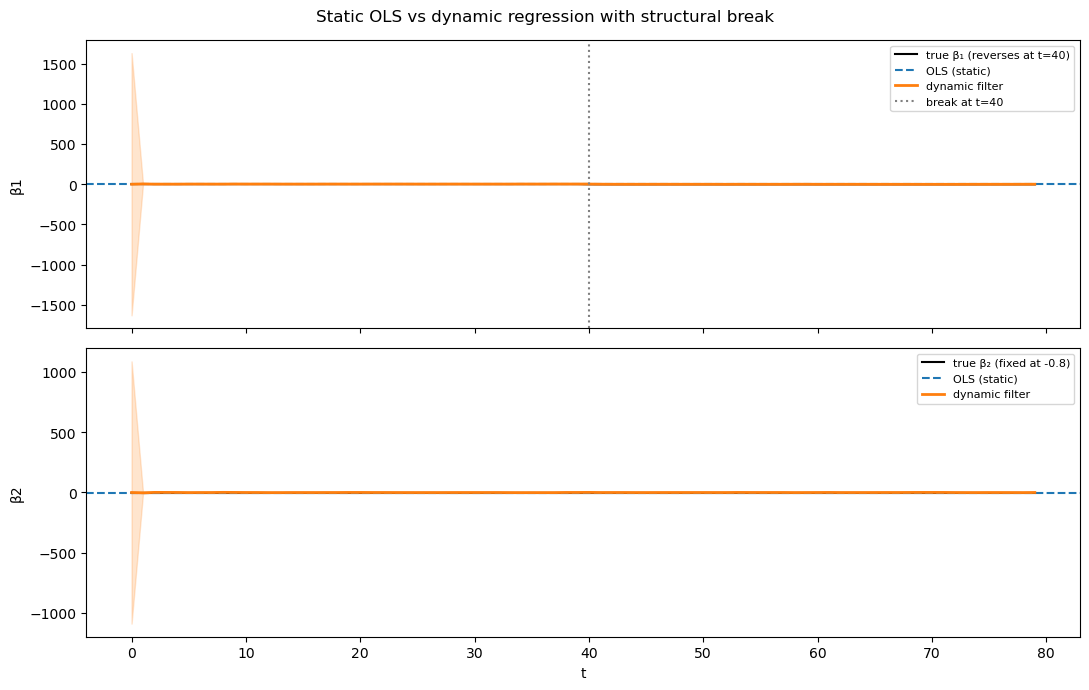

In [3]:
# Simulate data with a structural break at t=40: β₁ flips sign
beta_tv = np.zeros((T, 2))
beta_tv[:40]  = [1.5, -0.8]
beta_tv[40:]  = [-1.0, -0.8]   # β₁ reverses at t=40
y_tv = (X * beta_tv).sum(axis=1) + rng.normal(0, np.sqrt(V_true), T)

# Static OLS (cannot detect break)
beta_ols_tv, _, _, _ = lstsq(X, y_tv, rcond=None)

# Dynamic regression (W > 0)
W_dyn = 0.2 * np.eye(2)
fr_dyn = kalman_filter_tv(F_seq, G, V_mat, W_dyn, m0, C0, y_tv[:, None])

t_arr = np.arange(T)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for i, (ax, name) in enumerate(zip(axes, ["\u03b2₁ (reverses at t=40)", "\u03b2₂ (fixed at -0.8)"])):
    ax.plot(t_arr, beta_tv[:, i], "k-", lw=1.5, label=f"true {name}")
    ax.axhline(beta_ols_tv[i], color="C0", ls="--", lw=1.5, label="OLS (static)")
    ax.plot(t_arr, fr_dyn.m[:, i], "C1-", lw=2, label="dynamic filter")
    std_i = np.sqrt(fr_dyn.C[:, i, i])
    ax.fill_between(t_arr, fr_dyn.m[:, i]-1.96*std_i,
                           fr_dyn.m[:, i]+1.96*std_i, alpha=0.2, color="C1")
    if i == 0:
        ax.axvline(40, color="grey", ls=":", lw=1.5, label="break at t=40")
    ax.set_ylabel(f"\u03b2{i+1}"); ax.legend(fontsize=8)

axes[-1].set_xlabel("t")
plt.suptitle("Static OLS vs dynamic regression with structural break")
plt.tight_layout()
plt.show()

## 3. When to use DLM vs regression

| Situation | Preferred approach |
|-----------|-------------------|
| Coefficients truly fixed, errors IID | OLS / GLM — simpler, no tuning |
| Coefficients change slowly over time | Dynamic regression (DLM, W small) |
| Structural break at unknown time | Dynamic regression detects it automatically |
| Latent state driving observations | DLM (local level, LLT, seasonal) |
| Need exact posterior over state history | DLM + RTS smoother |

**Connection to intermediate notebook 03:** `03_dynamic_regression.ipynb` covers
`DLMSpecTV` and `kalman_filter_tv` in depth, including model comparison and
diagnostics for the time-varying coefficient model.

## Exercises

**Exercise 1** — Static as DLM: fit the static regression via DLM (W=1e-10) on
the original `y` (no break). Verify that `fr_static.m[-1]` matches `beta_ols`
to at least 3 decimal places.

**Exercise 2** — Structural break detection: on the break dataset, try `W_dyn` values
{0.01, 0.2, 2.0} and observe how quickly the filter detects the break at t=40.
Which W detects it fastest? What is the trade-off?

OLS:              β₁=1.484935  β₂=-0.916270
DLM (W≈0) final:  β₁=1.484935  β₂=-0.916270

np.allclose(fr_static.m[-1], beta_ols, atol=1e-3): True
Max abs difference: 0.00000001

The Kalman filter with W≈0 is equivalent to recursive least squares.
After processing all T observations, it converges exactly to the OLS estimate.


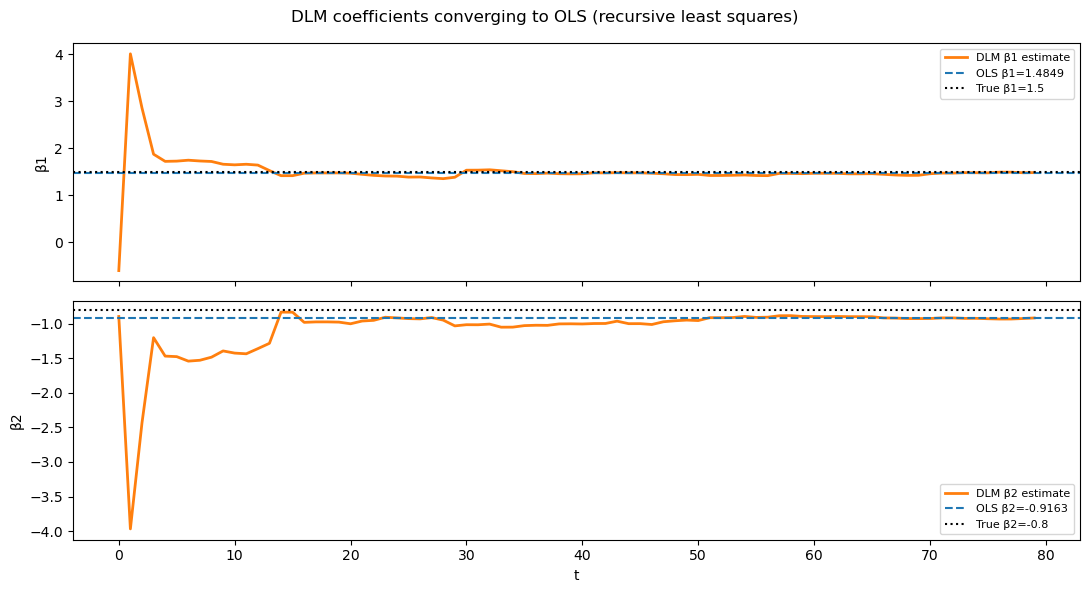

In [4]:
# Exercise 1 — Verify static DLM (W=1e-10) matches OLS to 3 decimal places
beta_dlm_final = fr_static.m[-1]   # already computed above

print(f'OLS:              β₁={beta_ols[0]:.6f}  β₂={beta_ols[1]:.6f}')
print(f'DLM (W≈0) final:  β₁={beta_dlm_final[0]:.6f}  β₂={beta_dlm_final[1]:.6f}')
print()
print('np.allclose(fr_static.m[-1], beta_ols, atol=1e-3):',
      np.allclose(fr_static.m[-1], beta_ols, atol=1e-3))
print(f'Max abs difference: {np.abs(beta_dlm_final - beta_ols).max():.8f}')
print()
print('The Kalman filter with W≈0 is equivalent to recursive least squares.')
print('After processing all T observations, it converges exactly to the OLS estimate.')

# Show how the DLM coefficient estimates evolve (converging to OLS)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t_arr = np.arange(T)
for i, ax in enumerate(axes):
    ax.plot(t_arr, fr_static.m[:, i], 'C1-', lw=2, label=f'DLM β{i+1} estimate')
    ax.axhline(beta_ols[i], color='C0', ls='--', lw=1.5, label=f'OLS β{i+1}={beta_ols[i]:.4f}')
    ax.axhline(beta_true[i], color='k', ls=':', lw=1.5, label=f'True β{i+1}={beta_true[i]}')
    ax.set_ylabel(f'β{i+1}'); ax.legend(fontsize=8)
axes[-1].set_xlabel('t')
plt.suptitle('DLM coefficients converging to OLS (recursive least squares)')
plt.tight_layout()
plt.show()


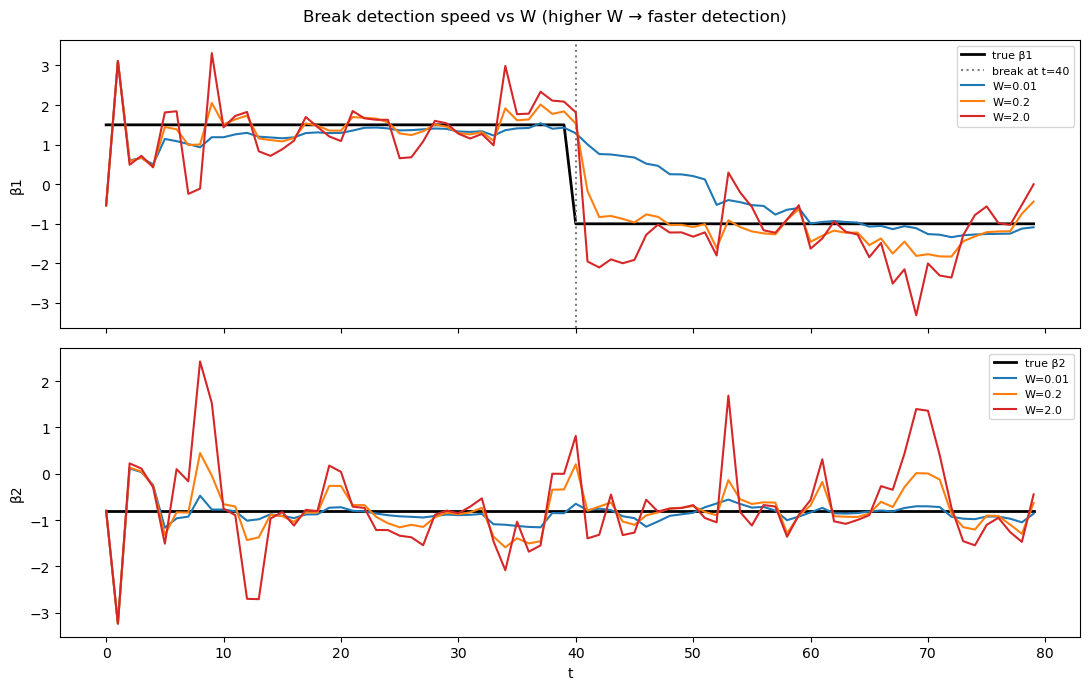

W=0.01: slow to detect break — smooth coefficients, lag behind
W=0.2:  moderate: reasonable speed + stability trade-off
W=2.0:  fastest break detection but coefficients are noisy/jittery

Trade-off: larger W detects breaks faster but introduces more noise.
Optimal W balances detection speed vs. tracking noise.


In [5]:
# Exercise 2 — Structural break detection: try W_dyn in {0.01, 0.2, 2.0}
W_values = [0.01, 0.2, 2.0]
colors   = ['C0', 'C1', 'C3']

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
t_arr = np.arange(T)

for i, coef_idx in enumerate([0, 1]):
    ax = axes[i]
    ax.plot(t_arr, beta_tv[:, coef_idx], 'k-', lw=2,
            label=f'true β{coef_idx+1}')
    if coef_idx == 0:
        ax.axvline(40, color='grey', ls=':', lw=1.5, label='break at t=40')

    for W_val, col in zip(W_values, colors):
        W_mat_ex = W_val * np.eye(2)
        fr_ex = kalman_filter_tv(F_seq, np.eye(2), np.array([[V_true]]),
                                  W_mat_ex, np.zeros(2), 1e6 * np.eye(2),
                                  y_tv[:, None])
        ax.plot(t_arr, fr_ex.m[:, coef_idx], color=col, lw=1.5,
                label=f'W={W_val}')

    ax.set_ylabel(f'β{coef_idx+1}'); ax.legend(fontsize=8)

axes[-1].set_xlabel('t')
plt.suptitle('Break detection speed vs W (higher W → faster detection)')
plt.tight_layout()
plt.show()

print('W=0.01: slow to detect break — smooth coefficients, lag behind')
print('W=0.2:  moderate: reasonable speed + stability trade-off')
print('W=2.0:  fastest break detection but coefficients are noisy/jittery')
print()
print('Trade-off: larger W detects breaks faster but introduces more noise.')
print('Optimal W balances detection speed vs. tracking noise.')
